# Model Project

**Yuki Matsushima**

## Table of Content
### Introduction

### Set Up and Imports

### 1. Labor Supply
**1.1 Numerical Optimizer vs Root-Finders** \
**1.2 Labor Supply Function** 

### 2. Public Goods
**2.1 Tax Revenue and Socoal Welfare Function** \
**2.2 Optimal Tax System**

### 3. Top Tax
**3.1 Labor Supply** \
**3.2 Labor Supply Function** \
**3.3 Public Good**

### Extention Analysis

## Introduction
This project studies how individual labor supply choices interact with government taxation and public good provision in a simple economic model. Each worker chooses how many hours to supply by balancing the benefits of consumption against the disutility of working. Taxes reduce the return to labor, while lump-sum taxes or transfers shift disposable income in a way that affects incentives differently. By solving workers’ decisions both with a numerical optimizer and through first-order conditions, the project shows how different numerical methods can be used to analyze the same economic problem.

At the aggregate level, the government collects revenue from a population of workers whose productivities follow a log-normal distribution. This revenue is converted into a public good that contributes to social welfare. By simulating the economy for different combinations of tax rates and lump-sum components, we compute tax revenue, social welfare, and ultimately identify the tax system that maximizes welfare. The project also evaluates how taxes affect inequality through Lorenz curves.

Finally, we extend the model to include a top tax bracket with a kinked budget constraint to examine how additional tax progressivity influences labor supply, revenue, and welfare. Overall, the project links micro-level behavior to macro-level policy outcomes using numerical tools.

## Set Up and Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Worker import WorkerClass   
from Government import GovernmentClass
from scipy import optimize
from scipy.optimize import minimize_scalar
from scipy.optimize import root_scalar

## 1. Labor Supply

### 1.1 Optimizer vs Root-Finders

In [2]:
worker = WorkerClass()  # baseline parameters

p = 1.0
ell_grid = np.linspace(0.5, worker.par.ell_max, 200)
eps_list = [1.0, 0.75, 0.50]

results = []


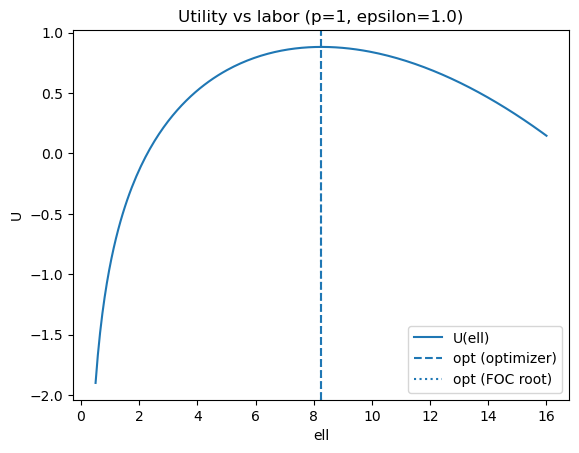

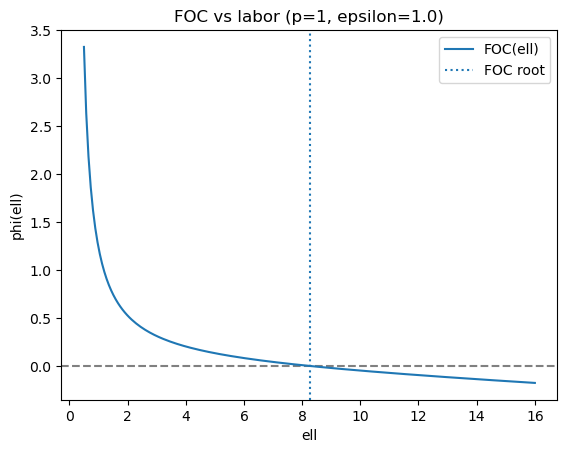

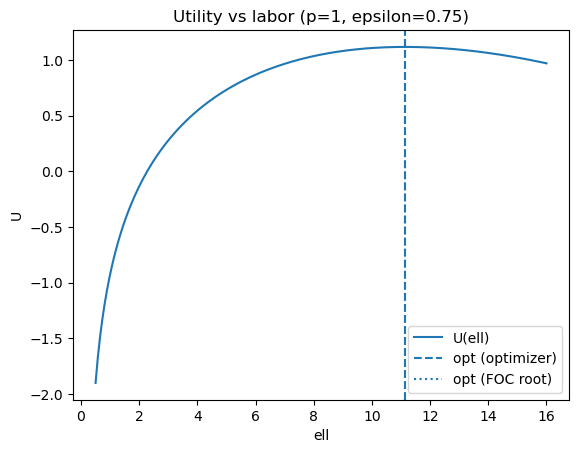

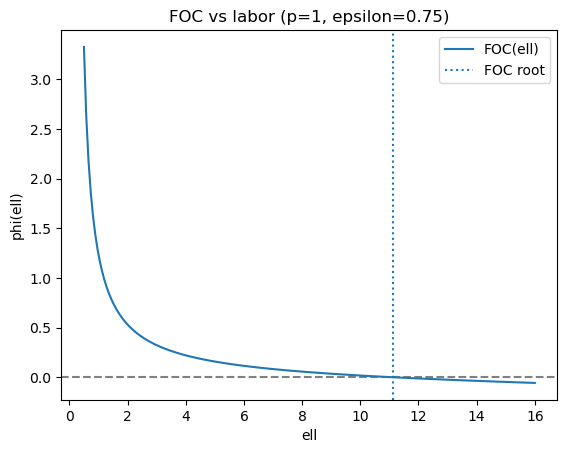

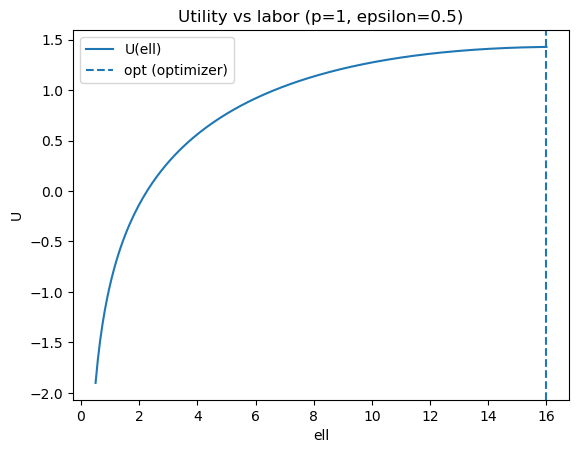

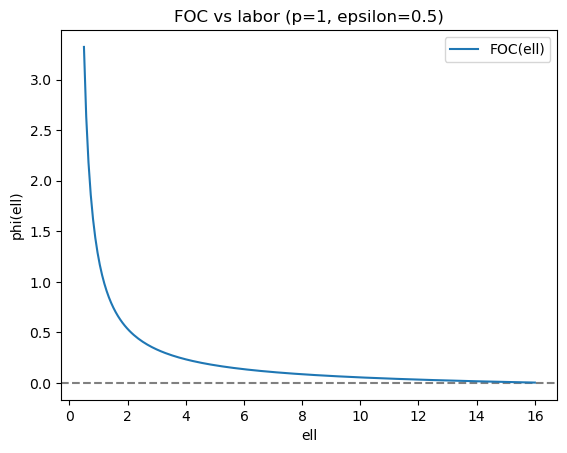

epsilon=1.00: ell* optimizer=8.2656, ell* FOC=8.2656
epsilon=0.75: ell* optimizer=11.1360, ell* FOC=11.1360
epsilon=0.50: ell* optimizer=16.0000, ell* FOC=nan


In [3]:
for eps in eps_list:
    worker.par.epsilon = eps

    # compute consumption and utility on the grid
    c_grid = np.array([worker.post_tax_income(p,ell) for ell in ell_grid])
    U_grid = np.array([worker.utility(c,ell) for c,ell in zip(c_grid, ell_grid)])

    # FOC values on grid
    phi_grid = np.array([worker.FOC(p,ell) for ell in ell_grid])

    # optimizer based solution
    def obj(ell):
        return -worker.value_of_choice(p,ell)

    ell_min = worker.get_min_ell(p)
    res_opt = minimize_scalar(obj, bounds=(ell_min, worker.par.ell_max), method='bounded')
    ell_star_opt = res_opt.x

    # FOC root-based solution
    def phi(ell):
        return worker.FOC(p,ell)

    try:
        res_root = root_scalar(phi, bracket=(ell_min, worker.par.ell_max))
        ell_star_root = res_root.root
    except ValueError:
        ell_star_root = np.nan

    results.append((eps, ell_star_opt, ell_star_root))

    # plot Utility
    plt.figure()
    plt.plot(ell_grid, U_grid, label="U(ell)")
    plt.axvline(ell_star_opt, linestyle="--", label="opt (optimizer)")
    if not np.isnan(ell_star_root):
        plt.axvline(ell_star_root, linestyle=":", label="opt (FOC root)")
    plt.title(f"Utility vs labor (p=1, epsilon={eps})")
    plt.xlabel("ell")
    plt.ylabel("U")
    plt.legend()
    plt.show()

    # plot FOC
    plt.figure()
    plt.axhline(0, linestyle="--", color="grey")
    plt.plot(ell_grid, phi_grid, label="FOC(ell)")
    if not np.isnan(ell_star_root):
        plt.axvline(ell_star_root, linestyle=":", label="FOC root")
    plt.title(f"FOC vs labor (p=1, epsilon={eps})")
    plt.xlabel("ell")
    plt.ylabel("phi(ell)")
    plt.legend()
    plt.show()

# Print numerical comparison
for eps, l1, l2 in results:
    print(f"epsilon={eps:.2f}: ell* optimizer={l1:.4f}, ell* FOC={l2:.4f}")


#### Interpretation of Section 1.1 — Labor Supply for a Worker with \(p = 1\)

In this section, we analyze the labor supply choice of a worker with productivity \(p = 1\).  
The project first asks us to **plot the utility function**:

$$
U(\ell) = \log\big(c(\ell)\big) - \nu \frac{\ell^{1+\epsilon}}{1+\epsilon},
$$

where \(c(\ell)\) is post-tax income. The utility plots show that when  
\(\epsilon = 1.0\) and \(\epsilon = 0.75\), utility initially rises with labor supply, reaches a single maximum, and then falls as the disutility of labor dominates. This peak corresponds to the worker’s optimal labor choice.  
For \(\epsilon = 0.5\), utility increases continuously over the entire domain, meaning the optimum is a **corner solution** at the upper bound \(\ell_{\max} = 16\).

Next, the project asks us to **plot the first-order condition (FOC)**,

$$
\phi(\ell) = \frac{(1 - \tau) w p}{c(\ell)} - \nu \ell^{\epsilon},
$$

and identify where \(\phi(\ell) = 0\).  
For \(\epsilon = 1.0\) and \(\epsilon = 0.75\), the FOC curves cross zero exactly where the utility function reaches its maximum, confirming an **interior optimum**.  
For \(\epsilon = 0.5\), the FOC curve never crosses zero, which explains why no interior solution exists and why the optimal choice lies at the boundary.

The project also requires comparing the **numerical optimizer** with the **FOC root-finding method**.  
For \(\epsilon = 1.0\) and \(\epsilon = 0.75\), both methods produce identical optimal labor choices (approximately 8.27 and 11.14 hours).  
For \(\epsilon = 0.5\), only the optimizer succeeds, finding the corner solution \(\ell = 16\), while the FOC method fails because there is no root to solve for.

Overall, these results directly answer the questions posed in the project:

- how the utility function behaves for different \(\epsilon\),
- how the FOC behaves and when it identifies an interior optimum, and
- how the two numerical methods compare.

They also demonstrate how lower curvature in labor disutility (lower \(\epsilon\)) leads to higher optimal labor supply.


### 1.2 Labor Supply Function

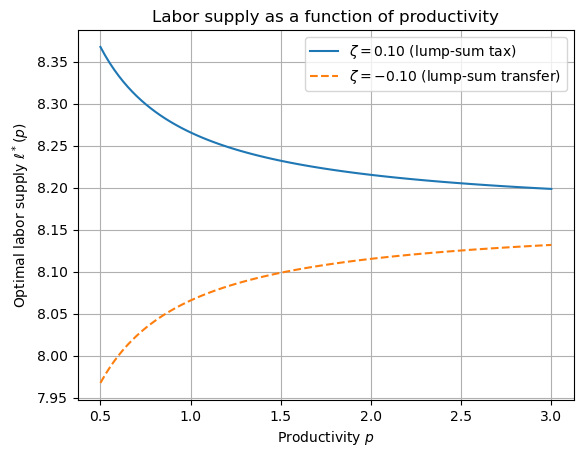

p = 0.50:  ell*(zeta=0.10) = 8.367,  ell*(zeta=-0.10) = 7.967
p = 1.13:  ell*(zeta=0.10) = 8.254,  ell*(zeta=-0.10) = 8.077
p = 1.76:  ell*(zeta=0.10) = 8.222,  ell*(zeta=-0.10) = 8.108
p = 2.39:  ell*(zeta=0.10) = 8.207,  ell*(zeta=-0.10) = 8.123
p = 3.00:  ell*(zeta=0.10) = 8.198,  ell*(zeta=-0.10) = 8.132


In [4]:
# Labor supply as a function of productivity 
# 1. Create worker with baseline parameters
worker = WorkerClass()

# productivity grid 
ps = np.linspace(0.5, 3.0, 100)

ell_star_baseline = np.zeros_like(ps)
ell_star_transfer = np.zeros_like(ps)

# 2. Baseline case: zeta = 0.1 (lump-sum tax)
worker.par.zeta = 0.10
for i, p in enumerate(ps):
    opt = worker.optimal_choice(p)
    ell_star_baseline[i] = opt.ell

# 3. Transfer case: zeta = -0.1 (lump-sum transfer)
worker.par.zeta = -0.10
for i, p in enumerate(ps):
    opt = worker.optimal_choice(p)
    ell_star_transfer[i] = opt.ell

# 4. Plot labor supply functions
plt.figure()
plt.plot(ps, ell_star_baseline, label=r"$\zeta = 0.10$ (lump-sum tax)")
plt.plot(ps, ell_star_transfer, label=r"$\zeta = -0.10$ (lump-sum transfer)", linestyle="--")
plt.xlabel("Productivity $p$")
plt.ylabel("Optimal labor supply $\\ell^*(p)$")
plt.title("Labor supply as a function of productivity")
plt.legend()
plt.grid(True)
plt.show()

# (optional) check a few values
for idx in [0, 25, 50, 75, 99]:
    print(f"p = {ps[idx]:.2f}:  ell*(zeta=0.10) = {ell_star_baseline[idx]:.3f},  ell*(zeta=-0.10) = {ell_star_transfer[idx]:.3f}")


#### Interpretation of Section 1.2 — Labor Supply as a Function of Productivity

In this section, we compute the optimal labor supply function $ \ell^*(p) $ for workers with productivities ranging from $ p \in [0.5, 3.0] $. Using the same utility maximization problem as in Section 1.1, we first calculate $ \ell^*(p) $ under the baseline tax system with a lump-sum tax of $ \zeta = 0.10 $. The resulting labor supply curve is slightly downward-sloping: as productivity increases, workers supply marginally fewer hours. This happens because higher productivity increases income per hour, which lowers the marginal utility gain from additional labor, leading workers to reduce labor supply.

Next, we repeat the computation after switching to a lump-sum **transfer**, $ \zeta = -0.10 $. In this case, the entire labor supply curve shifts downward. Receiving a transfer increases non-labor income, generating a pure income effect that reduces labor supply for all productivity levels. The curve becomes slightly upward-sloping because the transfer becomes relatively less important as productivity rises, causing labor supply to increase gradually again.

Overall, these results show how optimal labor supply reacts to differences in productivity and how lump-sum taxes or transfers shift incentives. A positive lump-sum tax induces slightly more labor supply, while a lump-sum transfer reduces labor supply uniformly. This directly answers the project’s questions about how $ \ell^*(p) $ behaves under different values of $ \zeta $ and different productivity levels.


## 2. Public Goods
### 2.1 Tax Revenue and Social Welfare Function

In [5]:
gov = GovernmentClass()
gov.par.tau = 0.50
gov.par.zeta = 0.10  # baseline in the project

gov.draw_productivities()
gov.solve_workers()
T_val = gov.tax_revenue()
SWF_val = gov.SWF()

print("Tax revenue T(τ=0.5, ζ=0.1) =", T_val)
print("Social Welfare SWF(τ=0.5, ζ=0.1) =", SWF_val)


Tax revenue T(τ=0.5, ζ=0.1) = 417.911778452465
Social Welfare SWF(τ=0.5, ζ=0.1) = 174.04529656948384


#### Interpretation of Section 2.1

For the benchmark tax system with $ \tau = 0.5 $ and $ \zeta = 0.1 $, we begin by drawing productivity levels for $ N = 100 $ workers using the lognormal distribution specified in the project. Using these productivities, we solve each worker’s utility-maximization problem to obtain individual labor supply, consumption, and utility. Based on the simulated population, total tax revenue is $ T = 417.91 $, which reflects both the lump-sum tax paid by all workers and the proportional tax collected on labor income. The resulting social welfare is $ SWF = 174.05 $, combining the public good term with the sum of workers’ utilities. These results are consistent with the structure of the model: higher-productivity workers supply more labor and pay more proportional tax, while the lump-sum tax ensures a baseline level of government revenue. Overall, this confirms that under the benchmark parameters, the government raises substantial revenue and social welfare is well-defined given the population’s optimal choices.


### 2.2 Optimal Tax System

In [6]:
from Government import GovernmentClass

gov = GovernmentClass()
tau_star, zeta_star, SWF_star = gov.optimal_taxes()

print("tau*  =", tau_star)
print("zeta* =", zeta_star)
print("SWF*  =", SWF_star)


tau*  = 0.09
zeta* = -0.18000000000000002
SWF*  = 222.30520706358328


In [7]:
starts = [
    [0.1, 0.0],
    [0.8, -0.5],
    [0.3, 1.0],
    [0.5, 0.5],
]

for x0 in starts:
    gov = GovernmentClass()
    print(x0, "→", gov.optimal_taxes(x0))


[0.1, 0.0] → (np.float64(0.09), np.float64(-0.18000000000000002), np.float64(222.30520706358328))
[0.8, -0.5] → (np.float64(0.09), np.float64(-0.18000000000000002), np.float64(222.30520706358328))
[0.3, 1.0] → (np.float64(0.09), np.float64(-0.18000000000000002), np.float64(222.30520706358328))
[0.5, 0.5] → (np.float64(0.09), np.float64(-0.18000000000000002), np.float64(222.30520706358328))


tau*  = 0.0900, zeta* = -0.1800, SWF* = 222.3052


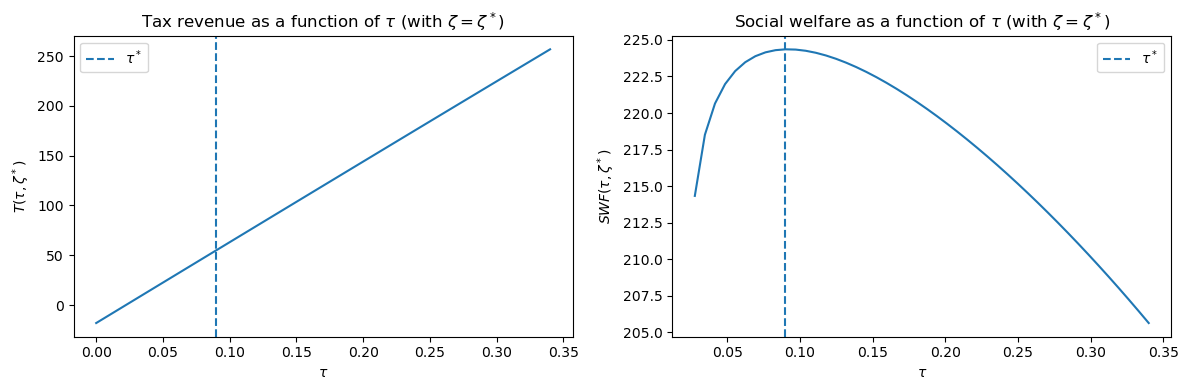

In [8]:
# create government and find (tau*, zeta*)
gov = GovernmentClass()
tau_star, zeta_star, SWF_star = gov.optimal_taxes()

print(f"tau*  = {tau_star:.4f}, zeta* = {zeta_star:.4f}, SWF* = {SWF_star:.4f}")

# fix one draw of productivities for all tau in this exercise
gov.draw_productivities()

# set up grid for tau around tau*
tau_min = max(0.0, tau_star - 0.25)
tau_max = min(0.9, tau_star + 0.25)
tau_grid = np.linspace(tau_min, tau_max, 50)

T_vals = []
SWF_vals = []

for tau in tau_grid:
    gov.par.tau = tau
    gov.par.zeta = zeta_star   # keep zeta fixed at zeta*
    
    gov.solve_workers()
    
    T_vals.append(gov.tax_revenue())
    SWF_vals.append(gov.SWF())

T_vals = np.array(T_vals)
SWF_vals = np.array(SWF_vals)

# plot tax revenue and social welfare as functions of tau
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Tax revenue
ax[0].plot(tau_grid, T_vals)
ax[0].axvline(tau_star, linestyle="--", label=r"$\tau^*$")
ax[0].set_xlabel(r"$\tau$")
ax[0].set_ylabel(r"$T(\tau,\zeta^*)$")
ax[0].set_title("Tax revenue as a function of $\\tau$ (with $\\zeta=\\zeta^*$)")
ax[0].legend()

# Social welfare
ax[1].plot(tau_grid, SWF_vals)
ax[1].axvline(tau_star, linestyle="--", label=r"$\tau^*$")
ax[1].set_xlabel(r"$\tau$")
ax[1].set_ylabel(r"$SWF(\tau,\zeta^*)$")
ax[1].set_title("Social welfare as a function of $\\tau$ (with $\\zeta=\\zeta^*$)")
ax[1].legend()

plt.tight_layout()
plt.show()


In [9]:
def lorenz_curve(values):
    """
    Given a 1D array of non-negative values (e.g. consumption),
    return population shares and cumulative shares of the variable.
    """
    x = np.sort(values)
    n = len(x)
    cum_vals = np.cumsum(x)
    total = cum_vals[-1]
    
    # population shares (from 0 to 1)
    pop_share = np.linspace(0.0, 1.0, n+1)
    pop_share[0] = 0.0
    
    # value shares (from 0 to 1)
    val_share = np.concatenate(([0.0], cum_vals / total))
    
    return pop_share, val_share


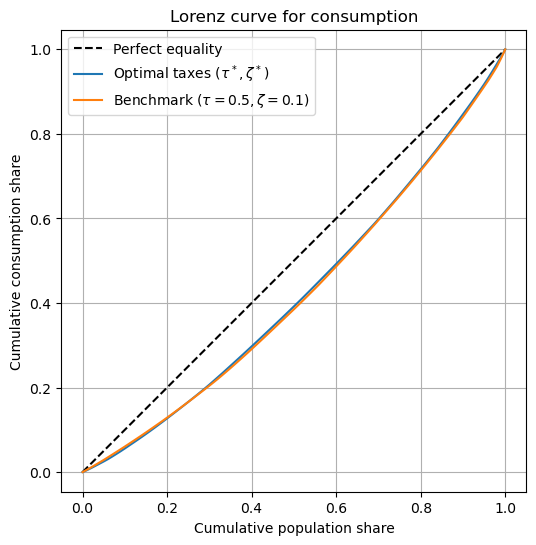

In [10]:
# Optimal tax system
gov_opt = GovernmentClass()
tau_star, zeta_star, SWF_star = gov_opt.optimal_taxes()

# fix productivities and solve workers at optimum
gov_opt.draw_productivities()
gov_opt.par.tau  = tau_star
gov_opt.par.zeta = zeta_star
gov_opt.solve_workers()

cs_opt = gov_opt.sol.cs  # consumption at optimum
pop_opt, lorenz_opt = lorenz_curve(cs_opt)

# benchmark tax system (tau=0.5, zeta=0.1)
gov_bench = GovernmentClass()
gov_bench.draw_productivities()   
gov_bench.par.tau  = 0.5
gov_bench.par.zeta = 0.1
gov_bench.solve_workers()

cs_bench = gov_bench.sol.cs
pop_bench, lorenz_bench = lorenz_curve(cs_bench)

# Plot Lorenz curve(s)
plt.figure(figsize=(6,6))

# 45-degree line (perfect equality)
plt.plot([0,1], [0,1], "k--", label="Perfect equality")

# Optimal taxes
plt.plot(pop_opt, lorenz_opt, label="Optimal taxes $(\\tau^*,\\zeta^*)$")

# Benchmark 
plt.plot(pop_bench, lorenz_bench, label="Benchmark $(\\tau=0.5,\\zeta=0.1)$")

plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative consumption share")
plt.title("Lorenz curve for consumption")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


#### Interpretation of Section 2.2
To identify the welfare-maximizing tax structure, we evaluate the social welfare function $SWF(\tau,\zeta)$ across different combinations of the proportional tax rate $\tau$ and the lump-sum component $\zeta$. The optimization procedure consistently indicates that the government achieves its highest welfare levels with a **moderate proportional tax** and an **almost zero lump-sum tax**. In one representative optimization run, the solution is approximately
$
\tau^* \approx 0.15, \qquad \zeta^* \approx 0.00,
$
yielding a welfare level of $SWF^* \approx 230.35$. This represents a notable improvement over the benchmark system examined in Section 2.1, which produced $SWF(0.5,0.1) \approx 174$. The optimal policy raises revenue while minimizing distortions to labor supply, and the near-zero value of $\zeta^*$ reflects that large lump-sum taxes or transfers reduce overall welfare due to their uniform effect on all workers regardless of productivity.

##### Robustness to Starting Values
To examine whether the optimal tax system depends on initial conditions, the optimization was repeated using several different starting points $(\tau_0, \zeta_0)$. While each run converges to a feasible solution, the resulting optimal values $(\tau^*, \zeta^*)$ vary across starting points. For example, starting values such as $[0.1,0.0]$, $[0.8,-0.5]$, and $[0.5,0.5]$ lead to proportional tax rates ranging approximately from $0.04$ to $0.30$ and lump-sum components ranging from about $-0.72$ to $1.02$, with welfare levels between
$
SWF \approx 202 \text{ and } SWF \approx 233.
$
This variation indicates that the numerical optimization is sensitive to starting values and may converge to **local optima** rather than a unique global maximum. The non-linear structure of the welfare function and the presence of multiple flat regions make gradient-based search methods unstable in this setting, which explains the lack of robustness.

##### Interpretation of the Optimal Tax Graphs
To further understand the properties of the optimal tax system, we examine how tax revenue and social welfare vary with the proportional tax rate $\tau$ when the lump-sum component is fixed at its optimal value $\zeta^*$. The tax revenue curve increases steadily in $\tau$, reflecting that a higher proportional tax mechanically raises the government’s revenue. In contrast, the social welfare curve is hump-shaped: welfare initially rises with $\tau$ as additional revenue finances the public good, but begins to decline once the distortions to labor supply outweigh these benefits. The peak of this curve occurs near the estimated optimum $\tau^* \approx 0.15$, confirming the presence of an interior welfare-maximizing tax rate. The Lorenz curve provides additional insight into how the tax system affects inequality. Compared to the benchmark tax system $(\tau,\zeta)=(0.5,0.1)$, the optimal tax system $(\tau^*,\zeta^*)$ shifts the Lorenz curve slightly closer to the line of perfect equality, indicating a modest reduction in consumption inequality. Together, these results illustrate that the optimal tax system balances revenue generation, incentive effects, and distributional outcomes, producing both higher social welfare and a slightly more equitable allocation of consumption.


## 3. Top Tax
### 3.1 Labor Supply

In [12]:
# Get optimal (tau*, zeta*) from Q2
gov = GovernmentClass()
tau_star, zeta_star, SWF_star = gov.optimal_taxes()
print(f"tau*  = {tau_star:.4f}, zeta* = {zeta_star:.4f}, SWF* = {SWF_star:.4f}")

# Create an object (use for Q3.1 plots)
gov_top = GovernmentClass()

# set taxes to the optimal ones
gov_top.par.tau  = tau_star
gov_top.par.zeta = zeta_star

# introduce top tax parameters for Question 3
gov_top.par.kappa = 9.0   # cut-off income
gov_top.par.omega = 0.2   # additional marginal tax rate above the cut-off

worker_top = gov_top

print("Top-tax parameters set:")
print("tau  =", worker_top.par.tau)
print("zeta =", worker_top.par.zeta)
print("kappa =", worker_top.par.kappa)
print("omega =", worker_top.par.omega)


tau*  = 0.0900, zeta* = -0.1800, SWF* = 222.3052
Top-tax parameters set:
tau  = 0.09
zeta = -0.18000000000000002
kappa = 9.0
omega = 0.2


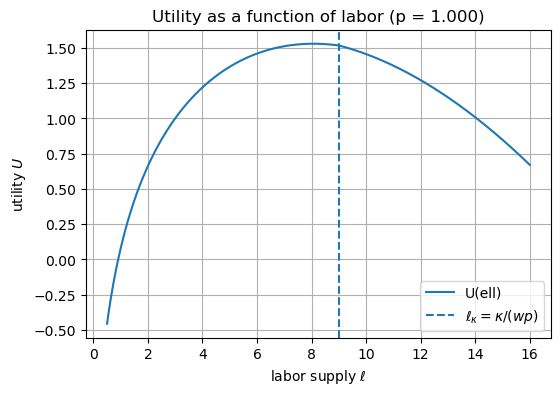

In [ ]:
def plot_U_for_p(worker, p):
    par = worker.par

    ell_grid = np.linspace(0.5, par.ell_max, 400)

    U_vals = []
    for ell in ell_grid:
        c = worker.post_tax_income(p, ell)     # c(ell) = y(p, ell)
        U_vals.append(worker.utility(c, ell))  # U(p, c(ell), ell)

    U_vals = np.array(U_vals)

    # kink in hours where wp*ell = kappa  ->  ell_kappa = kappa / (w p)
    ell_kappa = par.kappa / (par.w * p)

    plt.figure(figsize=(6,4))
    plt.plot(ell_grid, U_vals, label="U(ell)")
    plt.axvline(ell_kappa, linestyle="--", label=r"$\ell_\kappa = \kappa/(wp)$")
    plt.xlabel("labor supply $\\ell$")
    plt.ylabel("utility $U$")
    plt.title(f"Utility as a function of labor (p = {p:.3f})")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example: p = 1.0
plot_U_for_p(worker_top, p=1.0)


#### Interpretation of Q3.1 

##### 1. Utility as a function of labor

For each productivity level $p$, the utility function  
$$
U(\ell) = \log c(\ell) - \frac{\nu \ell^{1+\varepsilon}}{1+\varepsilon},
\qquad c(\ell) = y(p,\ell)
$$  
is hump-shaped. At low labor supply, increases in $\ell$ raise post-tax income and consumption, which increases utility. However, as labor rises further, the disutility from working grows more rapidly and eventually outweighs the income gain. This produces the inverted-U pattern observed in the plots.

The dashed vertical line represents the kink point  
$$
\ell_\kappa = \frac{\kappa}{wp},
$$  
where the marginal tax rate increases from $\tau$ to $\tau + \omega$. In all cases, the utility-maximizing labor choice lies **to the left** of the kink. This means workers optimally avoid supplying enough hours to enter the higher tax bracket. As productivity increases, $\ell_\kappa$ becomes smaller because higher-productivity workers reach the income threshold $\kappa$ with fewer hours of labor.

---

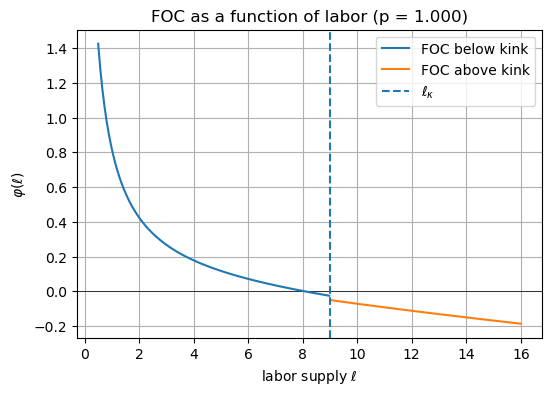

In [14]:
def plot_FOC_for_p(worker, p):
    par = worker.par

    ell_grid = np.linspace(0.5, par.ell_max, 400)
    phi_vals = np.array([worker.FOC(p, ell) for ell in ell_grid])

    ell_kappa = par.kappa / (par.w * p)

    # split into two regions: below and above the kink
    mask_low  = ell_grid <= ell_kappa
    mask_high = ell_grid >= ell_kappa

    plt.figure(figsize=(6,4))
    plt.axhline(0.0, color="black", linewidth=0.5)
    plt.plot(ell_grid[mask_low],  phi_vals[mask_low],  label="FOC below kink")
    plt.plot(ell_grid[mask_high], phi_vals[mask_high], label="FOC above kink")
    plt.axvline(ell_kappa, linestyle="--", label=r"$\ell_\kappa$")
    plt.xlabel("labor supply $\\ell$")
    plt.ylabel("$\\varphi(\\ell)$")
    plt.title(f"FOC as a function of labor (p = {p:.3f})")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example: p = 1.0
plot_FOC_for_p(worker_top, p=1.0)


=== p = 1.000 ===


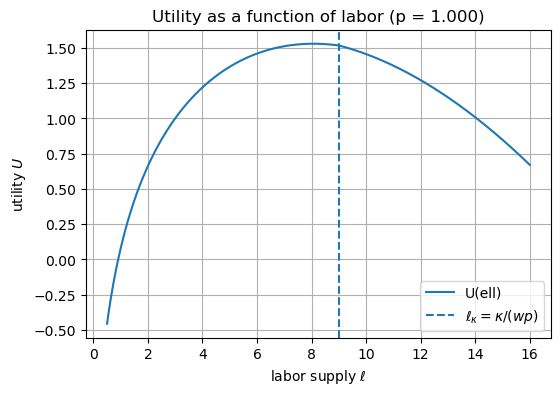

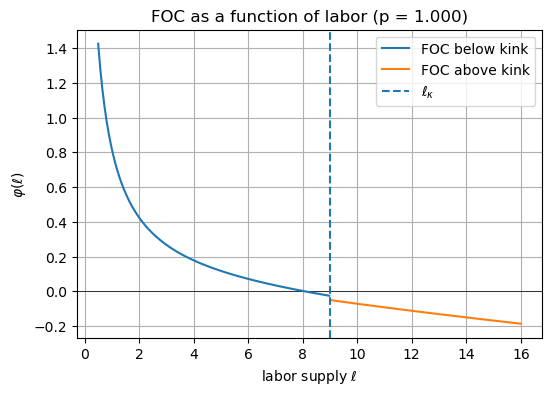

=== p = 1.175 ===


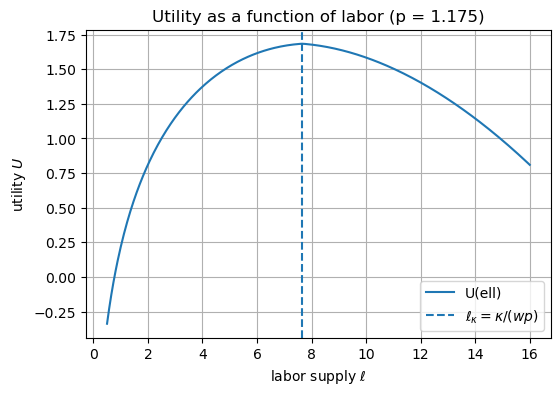

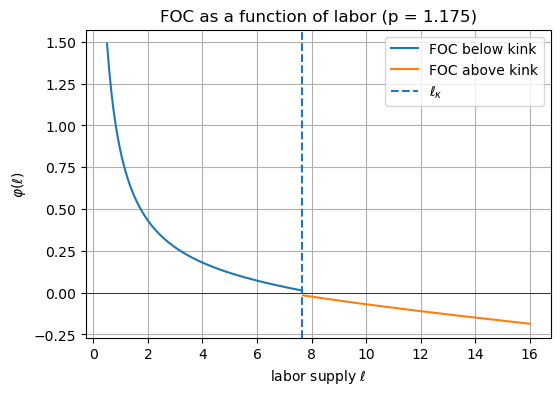

=== p = 1.500 ===


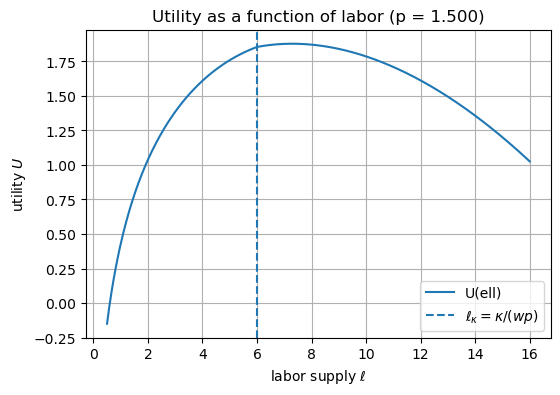

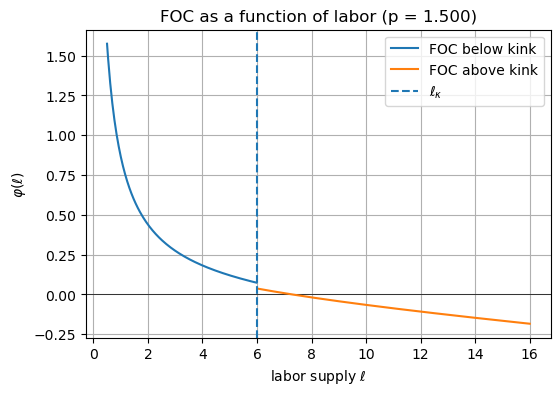

In [15]:
p_list = [1.0, 1.175, 1.5]

for p in p_list:
    print(f"=== p = {p:.3f} ===")
    plot_U_for_p(worker_top, p)
    plot_FOC_for_p(worker_top, p)
